## CLIP-ResNet + SLIC Validation

This notebook mirrors the `example.ipynb` single-image workflow, but loops over OpenAI CLIP ResNet backbones with `segmenter="slic"`.

B2a checks:
- B2a.1 `openai/clip-rn50`: model type stays `clip`, SLIC layout is produced, no crash.
- B2a.2 `openai/clip-rn101`: same checks plus peak memory report.
- B2a.3 `openai/clip-rn50x4`: same checks plus throughput report.
- B2.1 device check: SLIC keeps the CPU label map, caches it on the model device, and generates image masks on that device.

The OpenAI RN models are loaded through `clip.load("RN50")` / `clip.load("RN101")` / `clip.load("RN50x4")`. A small adapter below exposes the HuggingFace-like interface expected by `ImageImputerFactory`.


In [1]:
from pathlib import Path
from types import SimpleNamespace
import sys
import time

import numpy as np
import torch
torch.set_float32_matmul_precision("high")

import clip
from PIL import Image
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src
from ImputerFactory import ImageImputerFactory
from Game.game_huggingface import VisionLanguageGame

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


device: cuda


## OpenAI CLIP adapter

`ImageImputerFactory` expects a HuggingFace-like model and processor. Official OpenAI CLIP ResNet models expose `model(image, text_tokens)` instead, so this adapter keeps the notebook focused on B2a without changing project code.


In [11]:
class OpenAIClipBatch(dict):
    """Small BatchEncoding-like dict with a .tokens() helper for plotting."""

    def tokens(self):
        n_text_players = int(self["input_ids"].shape[1]) - 2
        return ["<s>"] + [f"tok_{i}" for i in range(n_text_players)] + ["</s>"]


class OpenAICLIPProcessorAdapter:
    """Processor adapter that returns pixel_values, input_ids, and attention_mask."""

    def __init__(self, preprocess, context_length=77):
        self.preprocess = preprocess
        self.context_length = int(context_length)
        self.image_processor = SimpleNamespace(
            image_mean=(0.48145466, 0.4578275, 0.40821073),
            image_std=(0.26862954, 0.26130258, 0.27577711),
        )

    @staticmethod
    def _as_list(value):
        if isinstance(value, (list, tuple)):
            return list(value)
        return [value]

    def __call__(self, images, text, return_tensors="pt", padding=True, max_length=None):
        images = self._as_list(images)
        texts = self._as_list(text)

        pixel_values = torch.stack([
            self.preprocess(img.convert("RGB") if hasattr(img, "convert") else Image.fromarray(np.asarray(img)).convert("RGB"))
            for img in images
        ])

        full_tokens = clip.tokenize(texts, context_length=self.context_length, truncate=True)
        lengths = []
        for row in full_tokens:
            nonzero = torch.nonzero(row, as_tuple=False).flatten()
            lengths.append(int(nonzero[-1].item()) + 1 if len(nonzero) else 2)
        short_len = max(lengths)
        input_ids = torch.zeros((len(texts), short_len), dtype=torch.long)
        attention_mask = torch.zeros((len(texts), short_len), dtype=torch.long)
        for i, length in enumerate(lengths):
            input_ids[i, :length] = full_tokens[i, :length]
            attention_mask[i, :length] = 1

        return OpenAIClipBatch(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
        )


class OpenAICLIPModelAdapter(torch.nn.Module):
    """HF-like wrapper around an official OpenAI CLIP model."""

    def __init__(self, clip_model, name_or_path):
        super().__init__()
        self.clip_model = clip_model
        self.name_or_path = name_or_path
        self.context_length = int(getattr(clip_model, "context_length", 77))
        image_size = int(getattr(clip_model.visual, "input_resolution", 224))

        self.config = SimpleNamespace(
            model_type="clip",
            vision_config=SimpleNamespace(image_size=image_size, num_channels=3),
        )
        # CNN-style signal for ImageImputerFactory: no embeddings.patch_size.
        self.vision_model = SimpleNamespace()

    def forward(self, pixel_values, input_ids, attention_mask):
        token_ids = input_ids.clone()
        token_ids = token_ids.masked_fill(attention_mask.to(token_ids.device) == 0, 0)

        if token_ids.shape[1] < self.context_length:
            pad = torch.zeros(
                (token_ids.shape[0], self.context_length - token_ids.shape[1]),
                dtype=token_ids.dtype,
                device=token_ids.device,
            )
            token_ids = torch.cat([token_ids, pad], dim=1)
        elif token_ids.shape[1] > self.context_length:
            token_ids = token_ids[:, :self.context_length]

        logits_per_image, logits_per_text = self.clip_model(pixel_values, token_ids)
        return SimpleNamespace(
            logits_per_image=logits_per_image,
            logits_per_text=logits_per_text,
        )


## Shared input and validation settings

`SMOKE_COALITIONS` keeps the default B2a pass light. Increase it if you want a stronger local throughput/memory check.


In [3]:
input_text = "black dog next to a yellow hydrant"
input_image = Image.open("assets/dog_and_hydrant.png").convert("RGB")

B2A_MODELS = [
    {"task": "B2a.1", "model_id": "openai/clip-rn50", "openai_name": "RN50", "backbone": "ResNet-50"},
    {"task": "B2a.2", "model_id": "openai/clip-rn101", "openai_name": "RN101", "backbone": "ResNet-101"},
    {"task": "B2a.3", "model_id": "openai/clip-rn50x4", "openai_name": "RN50x4", "backbone": "ResNet-50x4"},
]

BATCH_SIZE = 2
SMOKE_COALITIONS = 8
RANDOM_STATE = 0

# Full sign-off can be expensive. Keep False for quick no-crash validation.
RUN_AID_CHECK = True
AID_BUDGET = 2**19


In [ ]:
def reset_cuda_peak():
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats(DEVICE)
        torch.cuda.synchronize()


def cuda_peak_gb():
    if DEVICE.type != "cuda":
        return None
    torch.cuda.synchronize()
    return torch.cuda.max_memory_allocated(DEVICE) / (1024 ** 3)


def compute_aid_from_interactions(game, interaction_values):
    first_order = src.utils.convert_iv_to_first_order(interaction_values)
    attribution_values = first_order.get_n_order(1).values
    attribution_values_sorted = np.sort(attribution_values)

    coalition_mif = np.stack(
        [attribution_values <= v for v in attribution_values_sorted[::-1]]
        + [game.empty_coalition]
    )
    coalition_lif = np.stack(
        [attribution_values >= v for v in attribution_values_sorted]
        + [game.empty_coalition]
    )

    pred_mif = game.value_function(coalition_mif, batch_size=BATCH_SIZE)
    pred_lif = game.value_function(coalition_lif, batch_size=BATCH_SIZE)

    min_value = pred_mif[-1]
    max_value = pred_mif[0]
    if np.isclose(max_value, min_value):
        return np.nan

    pred_mif_norm = (pred_mif - min_value) / (max_value - min_value)
    pred_lif_norm = (pred_lif - min_value) / (max_value - min_value)
    return float(np.mean(pred_lif_norm - pred_mif_norm))


def validate_slic_device_scatter(imputer):
    seg = imputer.segmenter
    device = next(imputer.model.parameters()).device
    coalitions = np.ones((2, seg.n_players_image), dtype=bool)
    if seg.n_players_image > 1:
        coalitions[0, 1:] = False

    physical_mask = seg.generate_masks(coalitions_image=coalitions, device=device)
    image_mask = physical_mask.image_binary_mask
    cached_label_map = seg._label_map_for(device)

    assert seg._label_map.device.type == "cpu"
    assert cached_label_map.device == device
    assert image_mask.device == device
    assert tuple(image_mask.shape) == (2, imputer.n_channels, imputer.image_size, imputer.image_size)

    check = {
        "model_device": str(device),
        "slic_label_map_device": str(seg._label_map.device),
        "slic_cached_label_map_device": str(cached_label_map.device),
        "slic_mask_device": str(image_mask.device),
        "slic_mask_shape": tuple(image_mask.shape),
    }
    print("SLIC device scatter check:", check)
    return check


def run_b2a_model(spec):
    print(f"\n=== {spec['task']} {spec['model_id']} ({spec['backbone']}) ===")
    raw_model, preprocess = clip.load(spec["openai_name"], device=DEVICE, jit=False)
    raw_model.eval()

    model = OpenAICLIPModelAdapter(raw_model, spec["model_id"]).to(DEVICE).eval()
    processor = OpenAICLIPProcessorAdapter(preprocess, context_length=model.context_length)

    factory = ImageImputerFactory()
    imputer = factory.build(
        model,
        processor,
        input_image,
        input_text,
        segmenter="slic",
        masker="crossmodal_mean",
    )

    assert imputer.model_type == "clip"
    assert imputer.config.segmenter == "slic"
    assert imputer.layout.patch_size == 0
    assert imputer.n_players_image > 0
    slic_device_check = validate_slic_device_scatter(imputer)

    game = VisionLanguageGame(imputer, batch_size=BATCH_SIZE)

    rng = np.random.default_rng(RANDOM_STATE)
    coalitions = rng.random((SMOKE_COALITIONS, game.n_players)) > 0.5
    coalitions[0, :] = False
    coalitions[1, :] = True

    reset_cuda_peak()
    start = time.perf_counter()
    values = game.value_function(coalitions, batch_size=BATCH_SIZE)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    peak_gb = cuda_peak_gb()

    assert values.shape == (SMOKE_COALITIONS,)
    assert np.isfinite(values).all()

    aid = None
    interaction_values = None
    if RUN_AID_CHECK:
        fixlip = src.fixlip.FIxLIP(
            n_players_image=game.n_players_image,
            n_players_text=game.n_players_text,
            max_order=2,
            p=0.5,
            mode="banzhaf",
            random_state=RANDOM_STATE,
        )
        interaction_values = fixlip.approximate_crossmodal(game, budget=AID_BUDGET)
        aid = compute_aid_from_interactions(game, interaction_values)

    result = {
        "task": spec["task"],
        "model_id": spec["model_id"],
        "openai_name": spec["openai_name"],
        "model_type": imputer.model_type,
        "segmenter": imputer.config.segmenter,
        "masker": type(imputer.masker).__name__,
        "vision_masker": type(getattr(imputer.masker, "_vision_masker", None)).__name__,
        "n_players_image": game.n_players_image,
        "n_players_text": game.n_players_text,
        "image_size": imputer.image_size,
        "model_device": slic_device_check["model_device"],
        "slic_label_map_device": slic_device_check["slic_label_map_device"],
        "slic_cached_label_map_device": slic_device_check["slic_cached_label_map_device"],
        "slic_mask_device": slic_device_check["slic_mask_device"],
        "smoke_coalitions": SMOKE_COALITIONS,
        "elapsed_seconds": elapsed,
        "coalitions_per_second": SMOKE_COALITIONS / elapsed if elapsed > 0 else np.inf,
        "cuda_peak_gb": peak_gb,
        "empty_value": game.empty_value,
        "full_value": game.full_value,
        "aid": aid,
    }
    print(result)
    return result, game, interaction_values


## B2a.1/B2a.2/B2a.3 smoke validation

This is the required loop over CLIP-ResNet + `segmenter="slic"`. It verifies model detection, SLIC layout, no crash, memory, and throughput.


In [5]:
results = []
games = {}
interaction_values_by_model = {}

for spec in B2A_MODELS:
    result, game, interaction_values = run_b2a_model(spec)
    results.append(result)
    games[spec["model_id"]] = game
    if interaction_values is not None:
        interaction_values_by_model[spec["model_id"]] = interaction_values

try:
    import pandas as pd
    display(pd.DataFrame(results))
except ImportError:
    results



=== B2a.1 openai/clip-rn50 (ResNet-50) ===
SLIC device scatter check: {'model_device': 'cuda:0', 'slic_label_map_device': 'cpu', 'slic_cached_label_map_device': 'cuda:0', 'slic_mask_device': 'cuda:0', 'slic_mask_shape': (2, 3, 224, 224)}


c:\Users\Lishenna\anaconda3\envs\fixlip\lib\site-packages\torch\nn\functional.py:5560: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = scaled_dot_product_attention(q, k, v, attn_mask, dropout_p, is_causal)
<string>:12: UserWarning: Index FWBII is not a valid index as defined in {'SGV', 'k-SII', 'SII', 'kADD-SHAP', 'Moebius', 'BGV', 'EGV', 'Co-Moebius', 'EC', 'ELC', 'FBII', 'JointSV', 'STII', 'CHGV', 'CHII', 'BV', 'FSII', 'SV', 'IGV', 'BII'}. This might lead to unexpected behavior.


{'task': 'B2a.1', 'model_id': 'openai/clip-rn50', 'openai_name': 'RN50', 'model_type': 'clip', 'segmenter': 'slic', 'masker': 'CrossModalCompositeMasker', 'vision_masker': 'VisionMeanMasker', 'n_players_image': 31, 'n_players_text': 8, 'image_size': 224, 'model_device': 'cuda:0', 'slic_label_map_device': 'cpu', 'slic_cached_label_map_device': 'cuda:0', 'slic_mask_device': 'cuda:0', 'smoke_coalitions': 8, 'elapsed_seconds': 0.10192400000232738, 'coalitions_per_second': 78.48985518442491, 'cuda_peak_gb': 0.2616910934448242, 'empty_value': 15.484375, 'full_value': 29.765625, 'aid': 0.76220703125}

=== B2a.2 openai/clip-rn101 (ResNet-101) ===
SLIC device scatter check: {'model_device': 'cuda:0', 'slic_label_map_device': 'cpu', 'slic_cached_label_map_device': 'cuda:0', 'slic_mask_device': 'cuda:0', 'slic_mask_shape': (2, 3, 224, 224)}
{'task': 'B2a.2', 'model_id': 'openai/clip-rn101', 'openai_name': 'RN101', 'model_type': 'clip', 'segmenter': 'slic', 'masker': 'CrossModalCompositeMasker', '

,task,model_id,openai_name,model_type,segmenter,masker,vision_masker,n_players_image,n_players_text,image_size,...,slic_label_map_device,slic_cached_label_map_device,slic_mask_device,smoke_coalitions,elapsed_seconds,coalitions_per_second,cuda_peak_gb,empty_value,full_value,aid
0,B2a.1,openai/clip-rn50,RN50,clip,slic,CrossModalCompositeMasker,VisionMeanMasker,31,8,224,...,cpu,cuda:0,cuda:0,8,0.101924,78.489855,0.261691,15.484375,29.765625,0.762207
1,B2a.2,openai/clip-rn101,RN101,clip,slic,CrossModalCompositeMasker,VisionMeanMasker,31,8,224,...,cpu,cuda:0,cuda:0,8,0.086133,92.879616,0.537050,39.500000,52.468750,1.038086
2,B2a.3,openai/clip-rn50x4,RN50x4,clip,slic,CrossModalCompositeMasker,VisionMeanMasker,31,8,288,...,cpu,cuda:0,cuda:0,8,0.110317,72.518025,0.948561,32.125000,47.656250,0.746582


## Optional AID sign-off

For quick B2a no-crash validation, leave `RUN_AID_CHECK=False`. For final sign-off, set `RUN_AID_CHECK=True`, choose a larger `AID_BUDGET` (for example `2**19`, matching `example.ipynb`), rerun the validation loop, and compare the `aid` column against your ViT reference. The expected acceptance band is within +/-5% of the ViT-based result.


In [6]:
# Fill this with the AID from the original ViT example if you want an automatic check.
VIT_REFERENCE_AID = None

if VIT_REFERENCE_AID is not None:
    for row in results:
        if row["aid"] is None:
            continue
        relative_delta = abs(row["aid"] - VIT_REFERENCE_AID) / max(abs(VIT_REFERENCE_AID), 1e-12)
        row["aid_relative_delta"] = relative_delta
        row["aid_within_5pct"] = relative_delta <= 0.05
        print(row["model_id"], row["aid"], relative_delta, row["aid_within_5pct"])

    try:
        import pandas as pd
        display(pd.DataFrame(results))
    except ImportError:
        results


## Optional SLIC visualization for one validated model

`src.plot.plot_image_and_text_together()` assumes image players form a square ViT patch grid. SLIC players are non-uniform superpixels, so this cell uses the SLIC label map directly and visualizes first-order image/text values.


<string>:12: UserWarning: Index FWBII is not a valid index as defined in {'SGV', 'k-SII', 'SII', 'kADD-SHAP', 'Moebius', 'BGV', 'EGV', 'Co-Moebius', 'EC', 'ELC', 'FBII', 'JointSV', 'STII', 'CHGV', 'CHII', 'BV', 'FSII', 'SV', 'IGV', 'BII'}. This might lead to unexpected behavior.


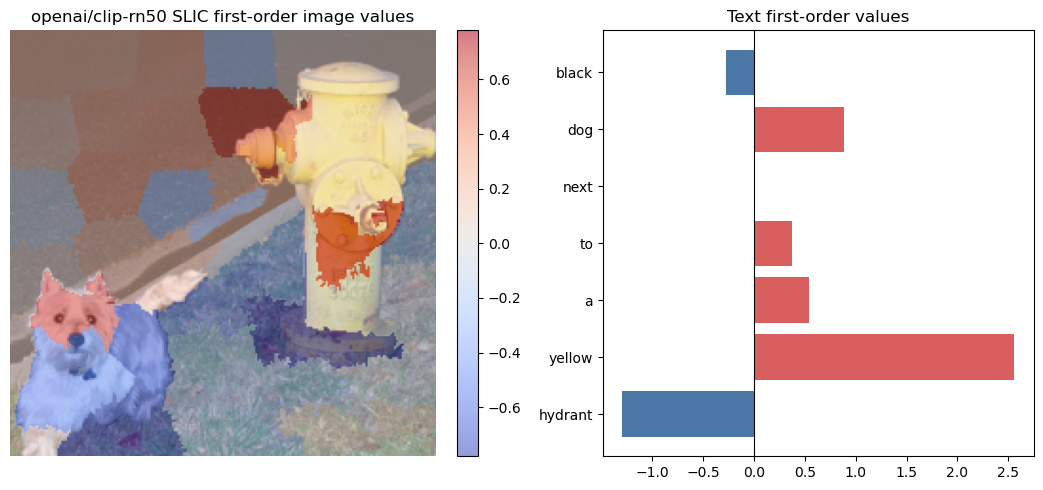

In [12]:
SELECTED_MODEL = "openai/clip-rn50"

selected_game = games[SELECTED_MODEL]
selected_iv = interaction_values_by_model.get(SELECTED_MODEL)
if selected_iv is None:
    raise RuntimeError(
        "No InteractionValues available for visualization. "
        "Set RUN_AID_CHECK=True and rerun the B2a validation loop first."
    )

text_tokens = input_text.split()
input_image_processed = selected_game.inputs["pixel_values"].squeeze(0)
input_image_denormalized = src.utils.denormalize(
    input_image_processed,
    selected_game.processor.image_processor.image_mean,
    selected_game.processor.image_processor.image_std,
).permute(1, 2, 0).numpy()

first_order_values = selected_iv.get_n_order(1).values
image_values = first_order_values[:selected_game.n_players_image]
text_values = first_order_values[selected_game.n_players_image:]

label_map = selected_game._imputer.segmenter._label_map.cpu().numpy()
superpixel_heatmap = image_values[label_map]
max_abs_image = np.quantile(np.abs(image_values), 0.99)
if max_abs_image <= 0 or not np.isfinite(max_abs_image):
    max_abs_image = 1.0

fig, axes = plt.subplots(1, 2, figsize=(11, 5), gridspec_kw={"width_ratios": [1.2, 1]})

axes[0].imshow(input_image_denormalized)
overlay = axes[0].imshow(
    superpixel_heatmap,
    cmap="coolwarm",
    alpha=0.55,
    vmin=-max_abs_image,
    vmax=max_abs_image,
)
axes[0].set_title(f"{SELECTED_MODEL} SLIC first-order image values")
axes[0].axis("off")
fig.colorbar(overlay, ax=axes[0], fraction=0.046, pad=0.04)

token_count = min(len(text_tokens), len(text_values))
tokens = text_tokens[:token_count]
values = text_values[:token_count]
bar_colors = ["#d95f5f" if value >= 0 else "#4c78a8" for value in values]
axes[1].barh(range(token_count), values, color=bar_colors)
axes[1].set_yticks(range(token_count))
axes[1].set_yticklabels(tokens)
axes[1].invert_yaxis()
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Text first-order values")

plt.tight_layout()
